# Configurable Market Classification Pipeline

This notebook tests whether historical bar data and derived features can predict the future return class of one or more market instruments.

The pipeline is intentionally configurable. The main inputs are set in the first code cell:

- Data source
- Symbols
- Bar intervals
- Number of target classes
- Forecast horizon
- Model list
- Conditional probability thresholds

The notebook can run one configuration or a grid of configurations. Each completed model run is appended to a master CSV so results can be compared over time.

## 1. Install dependencies

Run this cell once if the environment does not already have the required packages. The notebook supports both Yahoo Finance and Alpaca market data. Alpaca requires API credentials.

In [19]:
# Uncomment this line if needed in a fresh environment.
# %pip install -q yfinance alpaca-py scikit-learn matplotlib pandas numpy

## 2. Imports and configuration

Change the variables in this cell to control the full experiment.

For longer intraday history, use Alpaca as the data source and provide Alpaca API credentials. Yahoo Finance is convenient for daily bars, but its intraday history is limited.

In [ ]:
from __future__ import annotations

import os
import math
import warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# -----------------------------
# Core experiment controls
# -----------------------------
SEED = 42

# Select one or more data sources.
# Valid options: "yfinance", "alpaca"
DATA_SOURCES_TO_RUN = ["alpaca"]

# Select one or more symbols/instruments.
SYMBOLS = ["SLV"]

# Select one or more bar intervals.
# Examples: "1d", "1h", "30m", "15m", "5m"
TIME_UNITS = ["1h"]

# Select one or more class counts.
# 2 = lower/higher return classes
# 3 = lower/middle/higher return classes
# 5 = quintile-style return classes
NUMBER_OF_CLASSES_OPTIONS = [2]

# Predict the return this many bars into the future.
FORECAST_HORIZON_BARS = 1

# Request this many years of history.
LOOKBACK_YEARS = 10
START_DATE = None   # Optional override, e.g. "2016-01-01"
END_DATE = None     # Optional override, e.g. "2026-01-01"

# Conditional probability thresholds to evaluate.
# For example, [0.40, 0.45, 0.50, 0.55] will report each threshold separately.
CONDITIONAL_PROB_THRESHOLDS = [0.58]

# Optional context instruments. These are merged as additional features.
# For long intraday Alpaca tests, use instruments available from the same selected data source.
CONTEXT_SYMBOLS = []

# If True, a simple volatility-regime feature is fit using only training data inside each split.
USE_REGIME_FEATURE = True

# Offline test mode. Keep False for real experiments.
USE_SYNTHETIC_DATA = False

# -----------------------------
# Data source settings
# -----------------------------
YFINANCE_AUTO_ADJUST = True
YFINANCE_PERIOD_OVERRIDE = None  # Example: "730d". Leave None to use START_DATE/END_DATE.

ALPACA_API_KEY = ""
ALPACA_SECRET_KEY = ""
ALPACA_FEED = "iex"            # Common options: "iex" or "sip". SIP may require a paid data plan.
ALPACA_ADJUSTMENT = "raw"      # Common options: "raw", "split", "dividend", "all"

# -----------------------------
# Train/validation/test settings
# -----------------------------
TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20
TEST_FRACTION = 0.20

# Walk-forward settings.
# Use "Y" for annual folds, "Q" for quarterly folds, or "M" for monthly folds.
WALK_FORWARD_PERIOD = "Y"
MIN_WALK_FORWARD_TRAIN_PERIODS = 3
MIN_TRAIN_ROWS = 300
MIN_TEST_ROWS = 30

# -----------------------------
# Model settings
# -----------------------------
MODEL_SPECS = {
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=3,
        random_state=SEED,
    ),
}

PLOT_LOSS_CURVES = True
LOSS_CURVE_ESTIMATORS = [25, 50, 100, 150, 250]
MAX_LOSS_PLOTS = 8

# -----------------------------
# Output settings
# -----------------------------
RUN_LOG_DIR = Path("model_run_logs")
MASTER_LOG_PATH = RUN_LOG_DIR / "model_run_log_master.csv"
APPEND_TO_MASTER_LOG = True

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
np.random.seed(SEED)

print("Configuration loaded.")

Configuration loaded.


## 3. Data loading helpers

The data source is selected at the top of the notebook. Both loaders return the same normalized structure:

`timestamp, symbol, open, high, low, close, volume`

This makes the rest of the pipeline independent of the original data provider.

In [21]:
def resolve_date_range(start_date=None, end_date=None, lookback_years=10):
    """Return start/end timestamps for the requested experiment window."""
    end = pd.Timestamp(end_date) if end_date is not None else pd.Timestamp.utcnow().tz_localize(None)
    start = pd.Timestamp(start_date) if start_date is not None else end - pd.DateOffset(years=lookback_years)
    return start, end


def normalize_ohlcv(raw: pd.DataFrame, symbol: str) -> pd.DataFrame:
    """Normalize provider-specific OHLCV output into a consistent DataFrame."""
    if raw is None or len(raw) == 0:
        return pd.DataFrame()

    df = raw.copy()

    # yfinance can return MultiIndex columns even for single-symbol downloads in some versions.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0].lower() if isinstance(col, tuple) else str(col).lower() for col in df.columns]
    else:
        df.columns = [str(c).lower() for c in df.columns]

    # Move an index timestamp into a column if needed.
    if "timestamp" not in df.columns and "date" not in df.columns and "datetime" not in df.columns:
        df = df.reset_index()
        df.columns = [str(c).lower() for c in df.columns]

    # Standardize timestamp column name.
    rename_map = {}
    for candidate in ["timestamp", "datetime", "date"]:
        if candidate in df.columns:
            rename_map[candidate] = "timestamp"
            break
    df = df.rename(columns=rename_map)

    keep_cols = ["timestamp", "open", "high", "low", "close", "volume"]
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns after normalization: {missing}")

    df = df[keep_cols].copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce").dt.tz_convert(None)
    df["symbol"] = symbol

    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["timestamp", "open", "high", "low", "close", "volume"])
    df = df.drop_duplicates(subset=["timestamp", "symbol"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


def load_yfinance_data(symbol: str, time_unit: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """Load OHLCV bars from Yahoo Finance through yfinance."""
    try:
        import yfinance as yf
    except ImportError as exc:
        raise ImportError("Install yfinance or switch data source. Try: %pip install yfinance") from exc

    kwargs = dict(
        tickers=symbol,
        interval=time_unit,
        auto_adjust=YFINANCE_AUTO_ADJUST,
        progress=False,
        threads=True,
    )

    if YFINANCE_PERIOD_OVERRIDE:
        kwargs["period"] = YFINANCE_PERIOD_OVERRIDE
    else:
        kwargs["start"] = start.strftime("%Y-%m-%d")
        kwargs["end"] = end.strftime("%Y-%m-%d")

    raw = yf.download(**kwargs)
    df = normalize_ohlcv(raw, symbol)
    if df.empty:
        raise ValueError(f"No yfinance data returned for {symbol} at interval {time_unit}.")
    return df


def alpaca_timeframe_from_string(time_unit: str):
    """Convert a compact interval string into an alpaca-py TimeFrame."""
    try:
        from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
    except ImportError as exc:
        raise ImportError("Install alpaca-py or switch data source. Try: %pip install alpaca-py") from exc

    unit = str(time_unit).strip().lower()
    aliases = {
        "1min": "1m", "1minute": "1m", "1minute": "1m", "1hour": "1h", "1day": "1d",
        "day": "1d", "daily": "1d", "hour": "1h", "hourly": "1h",
    }
    unit = aliases.get(unit, unit)

    if unit.endswith("m") and unit[:-1].isdigit():
        return TimeFrame(int(unit[:-1]), TimeFrameUnit.Minute)
    if unit.endswith("h") and unit[:-1].isdigit():
        return TimeFrame(int(unit[:-1]), TimeFrameUnit.Hour)
    if unit.endswith("d") and unit[:-1].isdigit():
        return TimeFrame(int(unit[:-1]), TimeFrameUnit.Day)
    if unit.endswith("wk") and unit[:-2].isdigit():
        return TimeFrame(int(unit[:-2]), TimeFrameUnit.Week)
    if unit.endswith("mo") and unit[:-2].isdigit():
        return TimeFrame(int(unit[:-2]), TimeFrameUnit.Month)

    raise ValueError(f"Unsupported Alpaca time unit: {time_unit}")


def load_alpaca_data(symbol: str, time_unit: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """Load OHLCV bars from Alpaca Market Data through alpaca-py."""
    if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
        raise ValueError(
            "Alpaca credentials are missing. Set ALPACA_API_KEY and ALPACA_SECRET_KEY "
            "in the configuration cell or as environment variables."
        )

    try:
        from alpaca.data.historical import StockHistoricalDataClient
        from alpaca.data.requests import StockBarsRequest
        from alpaca.data.enums import Adjustment, DataFeed
    except ImportError as exc:
        raise ImportError("Install alpaca-py or switch data source. Try: %pip install alpaca-py") from exc

    timeframe = alpaca_timeframe_from_string(time_unit)
    client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)

    feed = getattr(DataFeed, ALPACA_FEED.upper())
    adjustment = getattr(Adjustment, ALPACA_ADJUSTMENT.upper())

    request = StockBarsRequest(
        symbol_or_symbols=[symbol],
        timeframe=timeframe,
        start=pd.Timestamp(start).to_pydatetime(),
        end=pd.Timestamp(end).to_pydatetime(),
        feed=feed,
        adjustment=adjustment,
    )

    bars = client.get_stock_bars(request)
    raw = bars.df.reset_index()

    # Alpaca returns a symbol column when requesting one or more symbols.
    if "symbol" in raw.columns:
        raw = raw[raw["symbol"] == symbol].copy()

    df = normalize_ohlcv(raw, symbol)
    if df.empty:
        raise ValueError(f"No Alpaca data returned for {symbol} at interval {time_unit}.")
    return df


def make_synthetic_data(symbol: str, time_unit: str, start: pd.Timestamp, end: pd.Timestamp, rows: int = 2500) -> pd.DataFrame:
    """Create synthetic OHLCV data for offline testing of notebook logic."""
    rng = np.random.default_rng(SEED + abs(hash((symbol, time_unit))) % 10000)
    freq = "D" if str(time_unit).lower().endswith("d") else "H"
    timestamps = pd.date_range(start=start, periods=rows, freq=freq)
    returns = rng.normal(0.0001, 0.012, size=rows)
    close = 100 * np.exp(np.cumsum(returns))
    open_ = close * (1 + rng.normal(0, 0.002, size=rows))
    high = np.maximum(open_, close) * (1 + rng.uniform(0.0005, 0.01, size=rows))
    low = np.minimum(open_, close) * (1 - rng.uniform(0.0005, 0.01, size=rows))
    volume = rng.integers(100_000, 3_000_000, size=rows)
    return pd.DataFrame({
        "timestamp": timestamps,
        "symbol": symbol,
        "open": open_,
        "high": high,
        "low": low,
        "close": close,
        "volume": volume,
    })


def load_market_data(symbol: str, time_unit: str, data_source: str) -> pd.DataFrame:
    """Load market data from the selected provider."""
    start, end = resolve_date_range(START_DATE, END_DATE, LOOKBACK_YEARS)
    source = str(data_source).strip().lower()

    if USE_SYNTHETIC_DATA:
        return make_synthetic_data(symbol, time_unit, start, end)
    if source == "yfinance":
        return load_yfinance_data(symbol, time_unit, start, end)
    if source == "alpaca":
        return load_alpaca_data(symbol, time_unit, start, end)

    raise ValueError(f"Unsupported data source: {data_source}")

## 4. Feature engineering helpers

All features are calculated from current and prior bars only. The future return is created separately and is excluded from the model inputs.

Feature windows are expressed in bars, not calendar days. For example, a 20-period rolling value means 20 daily bars for daily data or 20 hourly bars for hourly data.

In [22]:
def safe_divide(numerator, denominator):
    """Divide while avoiding infinite values."""
    out = numerator / denominator.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)


def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Relative Strength Index over a rolling window."""
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def add_primary_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add price, trend, volatility, volume, and calendar features."""
    data = df.copy().sort_values("timestamp").reset_index(drop=True)

    close = data["close"]
    high = data["high"]
    low = data["low"]
    open_ = data["open"]
    volume = data["volume"]

    # Return and momentum features.
    data["ret_1"] = close.pct_change(1)
    data["ret_lag1"] = data["ret_1"].shift(1)
    data["ret_lag2"] = data["ret_1"].shift(2)
    data["ret_lag3"] = data["ret_1"].shift(3)

    for window in [5, 10, 20, 50, 200]:
        data[f"mom_{window}"] = close.pct_change(window)

    # Trend features.
    for window in [10, 20, 50, 200]:
        data[f"_ma_{window}"] = close.rolling(window).mean()
        data[f"price_to_ma{window}"] = close / data[f"_ma_{window}"] - 1

    data["ma_cross"] = data["_ma_50"] / data["_ma_200"] - 1

    # Volatility and volume features.
    data["volatility_20"] = data["ret_1"].rolling(20).std()
    data["vol_ratio20"] = volume / volume.rolling(20).mean()
    data["vol_ratio50"] = volume / volume.rolling(50).mean()

    # RSI.
    data["rsi_14"] = rsi(close, 14)

    # MACD-style features.
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_signal = macd_raw.ewm(span=9, adjust=False).mean()
    data["macd"] = macd_raw / close
    data["macd_hist"] = (macd_raw - macd_signal) / close

    # Bollinger band position.
    ma_20 = close.rolling(20).mean()
    std_20 = close.rolling(20).std()
    bb_low = ma_20 - 2 * std_20
    bb_high = ma_20 + 2 * std_20
    data["bb_pct"] = (close - bb_low) / (bb_high - bb_low).replace(0, np.nan)

    # Average true range.
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    data["atr_14"] = tr.rolling(14).mean() / close

    # ADX-style trend strength.
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=data.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=data.index)
    atr = tr.rolling(14).mean()
    plus_di = 100 * plus_dm.rolling(14).sum() / atr.replace(0, np.nan)
    minus_di = 100 * minus_dm.rolling(14).sum() / atr.replace(0, np.nan)
    dx = ((plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)) * 100
    data["adx_14"] = dx.rolling(14).mean()

    # Money Flow Index.
    typical_price = (high + low + close) / 3
    money_flow = typical_price * volume
    positive_flow = pd.Series(np.where(typical_price.diff() > 0, money_flow, 0.0), index=data.index)
    negative_flow = pd.Series(np.where(typical_price.diff() < 0, money_flow, 0.0), index=data.index)
    money_ratio = positive_flow.rolling(14).sum() / negative_flow.rolling(14).sum().replace(0, np.nan)
    data["mfi_14"] = 100 - (100 / (1 + money_ratio))

    # Chaikin Money Flow.
    mfm = ((close - low) - (high - close)) / (high - low).replace(0, np.nan)
    mfv = mfm * volume
    data["cmf_20"] = mfv.rolling(20).sum() / volume.rolling(20).sum().replace(0, np.nan)

    # Current bar opening gap relative to the prior close.
    data["gap"] = open_ / close.shift(1) - 1

    # Position within the recent range.
    rolling_high = high.rolling(252).max()
    rolling_low = low.rolling(252).min()
    data["dist_252_high"] = close / rolling_high - 1
    data["dist_252_low"] = close / rolling_low - 1
    data["ret_norm"] = data["ret_1"] / data["volatility_20"].replace(0, np.nan)

    # Calendar features.
    ts = pd.to_datetime(data["timestamp"])
    data["dow_mon"] = (ts.dt.dayofweek == 0).astype(int)
    data["dow_tue"] = (ts.dt.dayofweek == 1).astype(int)
    data["dow_wed"] = (ts.dt.dayofweek == 2).astype(int)
    data["dow_thu"] = (ts.dt.dayofweek == 3).astype(int)

    # Hour-of-day cyclic features. For daily data this will usually be constant, which is harmless.
    hour = ts.dt.hour + ts.dt.minute / 60
    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    return data


def interval_to_timedelta(time_unit: str) -> pd.Timedelta:
    """Return a merge tolerance for a bar interval."""
    unit = str(time_unit).strip().lower()
    if unit.endswith("m") and unit[:-1].isdigit():
        return pd.Timedelta(minutes=int(unit[:-1]) * 2)
    if unit.endswith("h") and unit[:-1].isdigit():
        return pd.Timedelta(hours=int(unit[:-1]) * 2)
    if unit.endswith("d") and unit[:-1].isdigit():
        return pd.Timedelta(days=int(unit[:-1]) * 2)
    if unit.endswith("wk") and unit[:-2].isdigit():
        return pd.Timedelta(weeks=int(unit[:-2]) * 2)
    if unit.endswith("mo") and unit[:-2].isdigit():
        return pd.Timedelta(days=31 * int(unit[:-2]) * 2)
    return pd.Timedelta(days=2)


def clean_symbol_for_column(symbol: str) -> str:
    """Create a clean column suffix from an instrument symbol."""
    return "".join(ch if ch.isalnum() else "_" for ch in str(symbol).upper()).strip("_").lower()


def add_context_features(primary_df: pd.DataFrame, data_source: str, time_unit: str) -> pd.DataFrame:
    """Merge optional context instrument features into the primary dataset."""
    result = primary_df.copy().sort_values("timestamp")
    tolerance = interval_to_timedelta(time_unit)
    primary_symbol = str(result["symbol"].iloc[0]).upper() if len(result) else ""

    for context_symbol in CONTEXT_SYMBOLS:
        if str(context_symbol).upper() == primary_symbol:
            continue

        try:
            ctx = load_market_data(context_symbol, time_unit, data_source)
            ctx = ctx.sort_values("timestamp").reset_index(drop=True)
            prefix = f"ctx_{clean_symbol_for_column(context_symbol)}"
            ctx[f"{prefix}_ret_1"] = ctx["close"].pct_change(1)
            ctx[f"{prefix}_mom_10"] = ctx["close"].pct_change(10)
            ctx[f"{prefix}_volatility_20"] = ctx["close"].pct_change(1).rolling(20).std()
            ctx = ctx[["timestamp", f"{prefix}_ret_1", f"{prefix}_mom_10", f"{prefix}_volatility_20"]].dropna()

            result = pd.merge_asof(
                result.sort_values("timestamp"),
                ctx.sort_values("timestamp"),
                on="timestamp",
                direction="backward",
                tolerance=tolerance,
            )
        except Exception as exc:
            print(f"Skipping context symbol {context_symbol}: {exc}")

    return result


def add_future_return(df: pd.DataFrame, horizon_bars: int) -> pd.DataFrame:
    """Create the future return used for target labels."""
    data = df.copy().sort_values("timestamp")
    data["fwd_ret"] = data["close"].shift(-horizon_bars) / data["close"] - 1
    return data


def prepare_base_dataset(symbol: str, time_unit: str, data_source: str) -> pd.DataFrame:
    """Load raw data, create features, merge context inputs, and create future return."""
    raw = load_market_data(symbol, time_unit, data_source)
    data = add_primary_features(raw)
    data = add_context_features(data, data_source, time_unit)
    data = add_future_return(data, FORECAST_HORIZON_BARS)

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna().sort_values("timestamp").reset_index(drop=True)
    return data

## 5. Target labels, feature selection, and split helpers

The number of classes is controlled by `NUMBER_OF_CLASSES_OPTIONS`.

For two classes, the split is based on whether the future return is above or below zero. For more than two classes, the notebook learns quantile cutoffs from the training period only, then applies those same cutoffs to validation/test data.

In [23]:
def class_names(number_of_classes: int) -> List[str]:
    """Human-readable class names that work for any class count."""
    if number_of_classes == 2:
        return ["lower_return", "higher_return"]
    return [f"return_class_{i}" for i in range(number_of_classes)]


def fit_target_cutoffs(train_fwd_ret: pd.Series, number_of_classes: int) -> np.ndarray:
    """Fit return cutoffs using only the training period."""
    if number_of_classes < 2:
        raise ValueError("number_of_classes must be at least 2")
    if number_of_classes == 2:
        return np.array([0.0])

    quantiles = np.linspace(0, 1, number_of_classes + 1)[1:-1]
    cutoffs = np.quantile(train_fwd_ret.dropna(), quantiles)

    if len(np.unique(cutoffs)) != len(cutoffs):
        raise ValueError("Duplicate target cutoffs were produced. Try fewer classes or more data.")
    return cutoffs


def apply_target_cutoffs(fwd_ret: pd.Series, cutoffs: np.ndarray) -> pd.Series:
    """Apply fitted return cutoffs to create integer class labels."""
    return pd.Series(np.digitize(fwd_ret, cutoffs, right=True), index=fwd_ret.index).astype(int)


def add_regime_score(train_df: pd.DataFrame, other_dfs: List[pd.DataFrame]) -> Tuple[pd.DataFrame, List[pd.DataFrame]]:
    """Fit a simple volatility-regime score on training data and transform all supplied splits."""
    if not USE_REGIME_FEATURE or "volatility_20" not in train_df.columns:
        return train_df, other_dfs

    train = train_df.copy()
    others = [df.copy() for df in other_dfs]
    regime_cols = ["volatility_20"]

    try:
        x_train = train[regime_cols].replace([np.inf, -np.inf], np.nan).dropna()
        if len(x_train) < 50:
            raise ValueError("Not enough rows to fit regime feature.")

        gmm = GaussianMixture(n_components=2, random_state=SEED)
        gmm.fit(x_train)
        higher_vol_component = int(np.argmax(gmm.means_.ravel()))

        def transform(df):
            out = df.copy()
            x = out[regime_cols].replace([np.inf, -np.inf], np.nan)
            x = x.fillna(x_train.mean())
            out["regime_score"] = gmm.predict_proba(x)[:, higher_vol_component]
            return out

        train = transform(train)
        others = [transform(df) for df in others]
    except Exception:
        train["regime_score"] = 0.5
        for df in others:
            df["regime_score"] = 0.5

    return train, others


def get_feature_columns(df: pd.DataFrame) -> List[str]:
    """Return numeric model input columns while excluding target and raw OHLCV columns."""
    excluded = {
        "timestamp", "symbol", "open", "high", "low", "close", "volume",
        "fwd_ret", "target",
    }
    feature_cols = []
    for col in df.columns:
        if col in excluded or col.startswith("_"):
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            feature_cols.append(col)
    return feature_cols


def chronological_holdout_split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split data chronologically into train, validation, and test sets."""
    data = df.sort_values("timestamp").reset_index(drop=True)
    n = len(data)
    train_end = int(n * TRAIN_FRACTION)
    val_end = int(n * (TRAIN_FRACTION + VALIDATION_FRACTION))

    train = data.iloc[:train_end].copy()
    val = data.iloc[train_end:val_end].copy()
    test = data.iloc[val_end:].copy()

    if len(train) < MIN_TRAIN_ROWS or len(test) < MIN_TEST_ROWS:
        raise ValueError(f"Not enough rows after split. Train={len(train)}, Test={len(test)}")

    return train, val, test

## 6. Evaluation helpers

The notebook evaluates three levels of performance:

1. Baseline model performance
2. ML model performance
3. Conditional ML performance when the model is confident enough in the lowest or highest return class

For two-class runs, the lowest and highest classes correspond to the two directional classes. For multi-class runs, the middle classes are treated as non-extreme outcomes for conditional evaluation.

In [24]:
def aligned_predict_proba(model, X: pd.DataFrame, number_of_classes: int) -> np.ndarray:
    """Return predict_proba with one column per expected class."""
    raw_proba = model.predict_proba(X)
    aligned = np.zeros((len(X), number_of_classes))
    for i, cls in enumerate(model.classes_):
        if 0 <= int(cls) < number_of_classes:
            aligned[:, int(cls)] = raw_proba[:, i]
    return aligned


def safe_log_loss(y_true, proba, number_of_classes: int):
    """Compute log loss while handling edge cases."""
    try:
        return log_loss(y_true, proba, labels=list(range(number_of_classes)))
    except Exception:
        return np.nan


def class_accuracy(y_true, y_pred, class_id: int) -> float:
    """Accuracy within a single actual class; equivalent to recall for that class."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true == class_id
    if mask.sum() == 0:
        return np.nan
    return float((y_pred[mask] == class_id).mean())


def majority_baseline(y_train: pd.Series, y_eval: pd.Series, number_of_classes: int) -> Dict:
    """Evaluate a majority-class baseline."""
    majority_class = int(y_train.mode().iloc[0])
    pred = np.full(len(y_eval), majority_class)
    return {
        "Baseline Prediction - Majority": majority_class,
        "Baseline Accuracy - Majority": accuracy_score(y_eval, pred),
        "Baseline Macro F1 - Majority": f1_score(y_eval, pred, average="macro", labels=list(range(number_of_classes)), zero_division=0),
    }


def stratified_random_baseline(y_train: pd.Series, y_eval: pd.Series, number_of_classes: int) -> Dict:
    """Evaluate a random baseline that follows the training class distribution."""
    rng = np.random.default_rng(SEED)
    labels = np.arange(number_of_classes)
    train_dist = y_train.value_counts(normalize=True).reindex(labels, fill_value=0).values
    if train_dist.sum() == 0:
        train_dist = np.ones(number_of_classes) / number_of_classes
    pred = rng.choice(labels, size=len(y_eval), p=train_dist / train_dist.sum())
    return {
        "Baseline Accuracy - Stratified Random": accuracy_score(y_eval, pred),
        "Baseline Macro F1 - Stratified Random": f1_score(y_eval, pred, average="macro", labels=list(range(number_of_classes)), zero_division=0),
    }


def conditional_metrics(y_true, proba: np.ndarray, threshold: float, number_of_classes: int) -> Dict:
    """Evaluate only rows where the selected extreme class probability clears the threshold."""
    y_true = np.asarray(y_true)
    predicted_class = proba.argmax(axis=1)
    selected_prob = proba.max(axis=1)

    low_class = 0
    high_class = number_of_classes - 1

    low_mask = (predicted_class == low_class) & (selected_prob >= threshold)
    high_mask = (predicted_class == high_class) & (selected_prob >= threshold)
    directional_mask = low_mask | high_mask

    def mask_accuracy(mask, class_id):
        if mask.sum() == 0:
            return np.nan
        return float((y_true[mask] == class_id).mean())

    return {
        "Conditional Probability Threshold": threshold,
        "Conditional Accuracy Lowest Class - ML Model": mask_accuracy(low_mask, low_class),
        "Conditional Accuracy Highest Class - ML Model": mask_accuracy(high_mask, high_class),
        "Conditional Directional Accuracy - ML Model": float((y_true[directional_mask] == predicted_class[directional_mask]).mean()) if directional_mask.sum() else np.nan,
        "Conditional Coverage Lowest Class": float(low_mask.mean()),
        "Conditional Coverage Highest Class": float(high_mask.mean()),
        "Conditional Total Coverage": float(directional_mask.mean()),
        "Conditional Rows Lowest Class": int(low_mask.sum()),
        "Conditional Rows Highest Class": int(high_mask.sum()),
        "Conditional Rows Total": int(directional_mask.sum()),
        "Average Selected Probability": float(selected_prob[directional_mask].mean()) if directional_mask.sum() else np.nan,
    }


def evaluate_predictions(y_true, y_pred, proba, number_of_classes: int) -> Dict:
    """Core model metrics for one prediction set."""
    return {
        "ML Model Accuracy": accuracy_score(y_true, y_pred),
        "ML Model Macro F1": f1_score(y_true, y_pred, average="macro", labels=list(range(number_of_classes)), zero_division=0),
        "ML Model Weighted F1": f1_score(y_true, y_pred, average="weighted", labels=list(range(number_of_classes)), zero_division=0),
        "ML Model Log Loss": safe_log_loss(y_true, proba, number_of_classes),
        "ML Accuracy Lowest Class": class_accuracy(y_true, y_pred, 0),
        "ML Accuracy Highest Class": class_accuracy(y_true, y_pred, number_of_classes - 1),
    }


def plot_loss_curve(model_name: str, base_model, X_train, y_train, X_val, y_val, number_of_classes: int, title_suffix: str = ""):
    """Plot training and validation log loss for increasing ensemble sizes."""
    train_losses = []
    val_losses = []
    estimator_counts = []

    if not hasattr(base_model, "get_params") or "n_estimators" not in base_model.get_params():
        return

    for n_estimators in LOSS_CURVE_ESTIMATORS:
        model = clone(base_model)
        model.set_params(n_estimators=n_estimators)
        model.fit(X_train, y_train)

        train_proba = aligned_predict_proba(model, X_train, number_of_classes)
        val_proba = aligned_predict_proba(model, X_val, number_of_classes)

        train_losses.append(safe_log_loss(y_train, train_proba, number_of_classes))
        val_losses.append(safe_log_loss(y_val, val_proba, number_of_classes))
        estimator_counts.append(n_estimators)

    plt.figure(figsize=(8, 4))
    plt.plot(estimator_counts, train_losses, marker="o", label="Training loss")
    plt.plot(estimator_counts, val_losses, marker="o", label="Validation loss")
    plt.xlabel("Number of estimators")
    plt.ylabel("Log loss")
    plt.title(f"{model_name} Train vs Validation Loss {title_suffix}".strip())
    plt.legend()
    plt.show()

## 7. Holdout training and walk-forward validation

The holdout split gives a simple train/validation/test comparison. Walk-forward validation is more realistic because each fold trains only on data prior to the evaluated period.

In [25]:
def fit_prepared_splits(base_df: pd.DataFrame, number_of_classes: int):
    """Create targets and regime feature for the chronological holdout split."""
    train, val, test = chronological_holdout_split(base_df)

    cutoffs = fit_target_cutoffs(train["fwd_ret"], number_of_classes)
    train["target"] = apply_target_cutoffs(train["fwd_ret"], cutoffs)
    val["target"] = apply_target_cutoffs(val["fwd_ret"], cutoffs)
    test["target"] = apply_target_cutoffs(test["fwd_ret"], cutoffs)

    train, [val, test] = add_regime_score(train, [val, test])

    # Drop rows with missing values after target/regime creation.
    train = train.replace([np.inf, -np.inf], np.nan).dropna().copy()
    val = val.replace([np.inf, -np.inf], np.nan).dropna().copy()
    test = test.replace([np.inf, -np.inf], np.nan).dropna().copy()

    feature_cols = get_feature_columns(train)

    return train, val, test, cutoffs, feature_cols


def run_holdout_model(model_name: str, base_model, train, val, test, feature_cols, number_of_classes: int):
    """Train one model and evaluate it on validation and holdout test sets."""
    X_train, y_train = train[feature_cols], train["target"]
    X_val, y_val = val[feature_cols], val["target"]
    X_test, y_test = test[feature_cols], test["target"]

    model = clone(base_model)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_proba = aligned_predict_proba(model, X_val, number_of_classes)

    test_pred = model.predict(X_test)
    test_proba = aligned_predict_proba(model, X_test, number_of_classes)

    val_metrics = evaluate_predictions(y_val, val_pred, val_proba, number_of_classes)
    test_metrics = evaluate_predictions(y_test, test_pred, test_proba, number_of_classes)

    val_metrics = {f"Validation {k}": v for k, v in val_metrics.items()}
    test_metrics = {f"Holdout Test {k}": v for k, v in test_metrics.items()}

    return model, val_metrics, test_metrics, test_pred, test_proba


def run_walk_forward_model(base_df: pd.DataFrame, model_name: str, base_model, number_of_classes: int) -> pd.DataFrame:
    """Run walk-forward validation for one model."""
    data = base_df.copy().sort_values("timestamp").reset_index(drop=True)
    data["_period"] = pd.to_datetime(data["timestamp"]).dt.to_period(WALK_FORWARD_PERIOD)
    periods = sorted(data["_period"].dropna().unique())

    records = []

    for i in range(MIN_WALK_FORWARD_TRAIN_PERIODS, len(periods)):
        current_period = periods[i]
        train = data[data["_period"] < current_period].drop(columns=["_period"]).copy()
        test = data[data["_period"] == current_period].drop(columns=["_period"]).copy()

        if len(train) < MIN_TRAIN_ROWS or len(test) < MIN_TEST_ROWS:
            continue

        try:
            cutoffs = fit_target_cutoffs(train["fwd_ret"], number_of_classes)
            train["target"] = apply_target_cutoffs(train["fwd_ret"], cutoffs)
            test["target"] = apply_target_cutoffs(test["fwd_ret"], cutoffs)
            train, [test] = add_regime_score(train, [test])

            train = train.replace([np.inf, -np.inf], np.nan).dropna().copy()
            test = test.replace([np.inf, -np.inf], np.nan).dropna().copy()
            if len(train) < MIN_TRAIN_ROWS or len(test) < MIN_TEST_ROWS:
                continue

            feature_cols = get_feature_columns(train)
            X_train, y_train = train[feature_cols], train["target"]
            X_test, y_test = test[feature_cols], test["target"]

            if y_train.nunique() < number_of_classes:
                continue

            model = clone(base_model)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            proba = aligned_predict_proba(model, X_test, number_of_classes)

            fold = pd.DataFrame({
                "timestamp": test["timestamp"].values,
                "period": str(current_period),
                "y_true": y_test.values,
                "y_pred": pred,
            })
            for class_id in range(number_of_classes):
                fold[f"prob_class_{class_id}"] = proba[:, class_id]
            records.append(fold)
        except Exception as exc:
            print(f"Skipping walk-forward period {current_period} for {model_name}: {exc}")

    if records:
        return pd.concat(records, ignore_index=True)
    return pd.DataFrame()


def summarize_walk_forward(wf_df: pd.DataFrame, number_of_classes: int) -> Dict:
    """Summarize combined walk-forward predictions."""
    if wf_df.empty:
        return {
            "Walk Forward ML Model Accuracy": np.nan,
            "Walk Forward ML Model Macro F1": np.nan,
            "Walk Forward ML Accuracy Lowest Class": np.nan,
            "Walk Forward ML Accuracy Highest Class": np.nan,
            "Walk Forward Rows": 0,
            "Walk Forward Periods": 0,
        }

    y_true = wf_df["y_true"].values
    y_pred = wf_df["y_pred"].values
    return {
        "Walk Forward ML Model Accuracy": accuracy_score(y_true, y_pred),
        "Walk Forward ML Model Macro F1": f1_score(y_true, y_pred, average="macro", labels=list(range(number_of_classes)), zero_division=0),
        "Walk Forward ML Accuracy Lowest Class": class_accuracy(y_true, y_pred, 0),
        "Walk Forward ML Accuracy Highest Class": class_accuracy(y_true, y_pred, number_of_classes - 1),
        "Walk Forward Rows": int(len(wf_df)),
        "Walk Forward Periods": int(wf_df["period"].nunique()),
    }


def walk_forward_conditional_summary(wf_df: pd.DataFrame, threshold: float, number_of_classes: int) -> Dict:
    """Conditional accuracy summary from walk-forward predictions."""
    if wf_df.empty:
        empty = conditional_metrics([], np.empty((0, number_of_classes)), threshold, number_of_classes)
        return {f"Walk Forward {k}": v for k, v in empty.items()}

    proba_cols = [f"prob_class_{i}" for i in range(number_of_classes)]
    metrics = conditional_metrics(wf_df["y_true"].values, wf_df[proba_cols].values, threshold, number_of_classes)
    return {f"Walk Forward {k}": v for k, v in metrics.items()}

## 8. Run the configured experiments

This cell loops through every selected data source, symbol, bar interval, class count, and model. Each model is evaluated on both the holdout test set and walk-forward predictions.


Loading data | source=alpaca | symbol=SLV | interval=1h
Rows after feature engineering: 6,444 | 2020-09-14 15:00:00 to 2026-07-07 19:00:00

Class count: 2
Features: 36
Target cutoffs: [0.0]
Training model: Random Forest


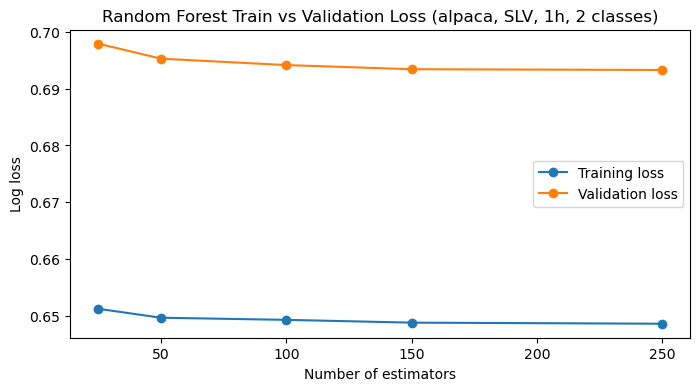

Training model: Gradient Boosting


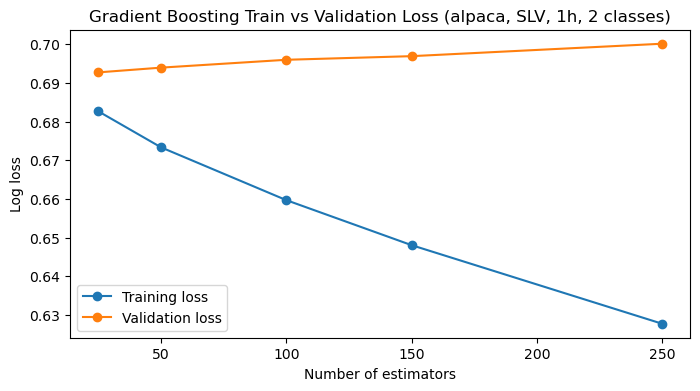

,Run ID,Run Timestamp,Data Source,Symbol,Time Unit,Number of Classes,Class Names,Forecast Horizon Bars,Requested Lookback Years,Actual Start Timestamp,Actual End Timestamp,Rows After Feature Engineering,Train Rows,Validation Rows,Holdout Test Rows,Number of Features,Feature Columns,Target Cutoffs,Training Class Distribution,Model,Baseline Prediction - Majority,Baseline Accuracy - Majority,Baseline Macro F1 - Majority,Baseline Accuracy - Stratified Random,Baseline Macro F1 - Stratified Random,Validation ML Model Accuracy,Validation ML Model Macro F1,Validation ML Model Weighted F1,Validation ML Model Log Loss,Validation ML Accuracy Lowest Class,Validation ML Accuracy Highest Class,Holdout Test ML Model Accuracy,Holdout Test ML Model Macro F1,Holdout Test ML Model Weighted F1,Holdout Test ML Model Log Loss,Holdout Test ML Accuracy Lowest Class,Holdout Test ML Accuracy Highest Class,Walk Forward ML Model Accuracy,Walk Forward ML Model Macro F1,Walk Forward ML Accuracy Lowest Class,Walk Forward ML Accuracy Highest Class,Walk Forward Rows,Walk Forward Periods,Holdout Test Conditional Probability Threshold,Holdout Test Conditional Accuracy Lowest Class - ML Model,Holdout Test Conditional Accuracy Highest Class - ML Model,Holdout Test Conditional Directional Accuracy - ML Model,Holdout Test Conditional Coverage Lowest Class,Holdout Test Conditional Coverage Highest Class,Holdout Test Conditional Total Coverage,Holdout Test Conditional Rows Lowest Class,Holdout Test Conditional Rows Highest Class,Holdout Test Conditional Rows Total,Holdout Test Average Selected Probability,Walk Forward Conditional Probability Threshold,Walk Forward Conditional Accuracy Lowest Class - ML Model,Walk Forward Conditional Accuracy Highest Class - ML Model,Walk Forward Conditional Directional Accuracy - ML Model,Walk Forward Conditional Coverage Lowest Class,Walk Forward Conditional Coverage Highest Class,Walk Forward Conditional Total Coverage,Walk Forward Conditional Rows Lowest Class,Walk Forward Conditional Rows Highest Class,Walk Forward Conditional Rows Total,Walk Forward Average Selected Probability
1,20260709_201742,2026-07-09T20:19:22,alpaca,SLV,1h,2,"lower_return, higher_return",1,10,2020-09-14 15:00:00,2026-07-07 19:00:00,6444,3866,1289,1289,36,"ret_1, ret_lag1, ret_lag2, ret_lag3, mom_5, mo...",0.00000000,"{0: 0.5178479048111744, 1: 0.4821520951888257}",Gradient Boosting,0,0.458495,0.314362,0.50737,0.507227,0.502715,0.490195,0.491125,0.700121,0.651840,0.350078,0.484872,0.484820,0.484388,0.730283,0.539763,0.438395,0.515650,0.514568,0.561376,0.469681,3770,4,0.58,0.433962,0.517375,0.475191,0.205586,0.200931,0.406517,265,259,524,0.661967,0.58,0.474699,0.537162,0.511420,0.110080,0.157029,0.267109,415,592,1007,0.641145
0,20260709_201742,2026-07-09T20:17:54,alpaca,SLV,1h,2,"lower_return, higher_return",1,10,2020-09-14 15:00:00,2026-07-07 19:00:00,6444,3866,1289,1289,36,"ret_1, ret_lag1, ret_lag2, ret_lag3, mom_5, mo...",0.00000000,"{0: 0.5178479048111744, 1: 0.4821520951888257}",Random Forest,0,0.458495,0.314362,0.50737,0.507227,0.505818,0.505474,0.505626,0.693259,0.526074,0.485086,0.531420,0.513857,0.521527,0.691583,0.372250,0.666189,0.520955,0.520955,0.519577,0.522340,3770,4,0.58,1.000000,0.565517,0.590909,0.006982,0.112490,0.119472,9,145,154,0.622627,0.58,0.625000,0.590909,0.594262,0.006366,0.058355,0.064721,24,220,244,0.611648


In [26]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
all_log_rows = []
loss_plots_created = 0

for data_source in DATA_SOURCES_TO_RUN:
    for symbol in SYMBOLS:
        for time_unit in TIME_UNITS:
            print(f"\nLoading data | source={data_source} | symbol={symbol} | interval={time_unit}")

            try:
                base_df = prepare_base_dataset(symbol, time_unit, data_source)
                if len(base_df) < (MIN_TRAIN_ROWS + MIN_TEST_ROWS):
                    raise ValueError(f"Not enough usable rows after feature engineering: {len(base_df)}")

                actual_start = base_df["timestamp"].min()
                actual_end = base_df["timestamp"].max()
                print(f"Rows after feature engineering: {len(base_df):,} | {actual_start} to {actual_end}")
            except Exception as exc:
                print(f"Skipping configuration because data could not be prepared: {exc}")
                continue

            for number_of_classes in NUMBER_OF_CLASSES_OPTIONS:
                print(f"\nClass count: {number_of_classes}")

                try:
                    train, val, test, cutoffs, feature_cols = fit_prepared_splits(base_df, number_of_classes)
                except Exception as exc:
                    print(f"Skipping class count {number_of_classes}: {exc}")
                    continue

                baseline_majority = majority_baseline(train["target"], test["target"], number_of_classes)
                baseline_random = stratified_random_baseline(train["target"], test["target"], number_of_classes)
                class_dist = train["target"].value_counts(normalize=True).sort_index().to_dict()

                print(f"Features: {len(feature_cols)}")
                print(f"Target cutoffs: {np.round(cutoffs, 6).tolist()}")

                for model_name, model_spec in MODEL_SPECS.items():
                    print(f"Training model: {model_name}")

                    try:
                        model, val_metrics, test_metrics, test_pred, test_proba = run_holdout_model(
                            model_name, model_spec, train, val, test, feature_cols, number_of_classes
                        )

                        if PLOT_LOSS_CURVES and loss_plots_created < MAX_LOSS_PLOTS:
                            plot_loss_curve(
                                model_name,
                                model_spec,
                                train[feature_cols],
                                train["target"],
                                val[feature_cols],
                                val["target"],
                                number_of_classes,
                                title_suffix=f"({data_source}, {symbol}, {time_unit}, {number_of_classes} classes)",
                            )
                            loss_plots_created += 1

                        wf_df = run_walk_forward_model(base_df, model_name, model_spec, number_of_classes)
                        wf_summary = summarize_walk_forward(wf_df, number_of_classes)

                        for threshold in CONDITIONAL_PROB_THRESHOLDS:
                            holdout_conditional = conditional_metrics(
                                test["target"].values,
                                test_proba,
                                threshold,
                                number_of_classes,
                            )
                            holdout_conditional = {f"Holdout Test {k}": v for k, v in holdout_conditional.items()}
                            wf_conditional = walk_forward_conditional_summary(wf_df, threshold, number_of_classes)

                            row = {
                                "Run ID": run_id,
                                "Run Timestamp": datetime.now().isoformat(timespec="seconds"),
                                "Data Source": data_source,
                                "Symbol": symbol,
                                "Time Unit": time_unit,
                                "Number of Classes": number_of_classes,
                                "Class Names": ", ".join(class_names(number_of_classes)),
                                "Forecast Horizon Bars": FORECAST_HORIZON_BARS,
                                "Requested Lookback Years": LOOKBACK_YEARS,
                                "Actual Start Timestamp": actual_start,
                                "Actual End Timestamp": actual_end,
                                "Rows After Feature Engineering": len(base_df),
                                "Train Rows": len(train),
                                "Validation Rows": len(val),
                                "Holdout Test Rows": len(test),
                                "Number of Features": len(feature_cols),
                                "Feature Columns": ", ".join(feature_cols),
                                "Target Cutoffs": ", ".join([f"{x:.8f}" for x in cutoffs]),
                                "Training Class Distribution": str(class_dist),
                                "Model": model_name,
                                **baseline_majority,
                                **baseline_random,
                                **val_metrics,
                                **test_metrics,
                                **wf_summary,
                                **holdout_conditional,
                                **wf_conditional,
                            }
                            all_log_rows.append(row)
                    except Exception as exc:
                        print(f"Skipping model {model_name}: {exc}")

results_df = pd.DataFrame(all_log_rows)

if results_df.empty:
    print("No completed model runs. Check the configuration, data availability, and credentials.")
else:
    display(results_df.sort_values(["Data Source", "Symbol", "Time Unit", "Number of Classes", "Model", "Holdout Test Conditional Probability Threshold"]))

## 9. Append results to the master CSV

Every row represents one completed configuration/model/threshold combination. New notebook runs append rows to the same CSV instead of creating a separate file.

In [28]:
if not results_df.empty:
    RUN_LOG_DIR.mkdir(parents=True, exist_ok=True)

    # Keep one master CSV. If the column structure changed between notebook versions,
    # align columns before saving so the file remains readable.
    if APPEND_TO_MASTER_LOG and MASTER_LOG_PATH.exists():
        try:
            existing_df = pd.read_csv(MASTER_LOG_PATH)
            all_columns = list(dict.fromkeys(list(existing_df.columns) + list(results_df.columns)))
            combined_df = pd.concat(
                [existing_df.reindex(columns=all_columns), results_df.reindex(columns=all_columns)],
                ignore_index=True,
            )
            combined_df.to_csv(MASTER_LOG_PATH, index=False)
            print(f"Appended {len(results_df)} rows to {MASTER_LOG_PATH}")
        except Exception as exc:
            backup_path = MASTER_LOG_PATH.with_name(MASTER_LOG_PATH.stem + f"_backup_{run_id}.csv")
            MASTER_LOG_PATH.rename(backup_path)
            results_df.to_csv(MASTER_LOG_PATH, index=False)
            print(f"Existing log could not be read cleanly, so it was backed up to {backup_path}")
            print(f"Created a fresh readable master log at {MASTER_LOG_PATH}")
    else:
        results_df.to_csv(MASTER_LOG_PATH, index=False)
        print(f"Created {MASTER_LOG_PATH} with {len(results_df)} rows")

    master_df = pd.read_csv(MASTER_LOG_PATH)
    display(master_df.tail(min(20, len(master_df))))
else:
    print("No results to save.")

Appended 2 rows to model_run_logs\model_run_log_master.csv


,Run ID,Run Timestamp,Data Source,Symbol,Time Unit,Number of Classes,Class Names,Forecast Horizon Bars,Requested Lookback Years,Actual Start Timestamp,Actual End Timestamp,Rows After Feature Engineering,Train Rows,Validation Rows,Holdout Test Rows,Number of Features,Feature Columns,Target Cutoffs,Training Class Distribution,Model,Baseline Prediction - Majority,Baseline Accuracy - Majority,Baseline Macro F1 - Majority,Baseline Accuracy - Stratified Random,Baseline Macro F1 - Stratified Random,Validation ML Model Accuracy,Validation ML Model Macro F1,Validation ML Model Weighted F1,Validation ML Model Log Loss,Validation ML Accuracy Lowest Class,Validation ML Accuracy Highest Class,Holdout Test ML Model Accuracy,Holdout Test ML Model Macro F1,Holdout Test ML Model Weighted F1,Holdout Test ML Model Log Loss,Holdout Test ML Accuracy Lowest Class,Holdout Test ML Accuracy Highest Class,Walk Forward ML Model Accuracy,Walk Forward ML Model Macro F1,Walk Forward ML Accuracy Lowest Class,Walk Forward ML Accuracy Highest Class,Walk Forward Rows,Walk Forward Periods,Holdout Test Conditional Probability Threshold,Holdout Test Conditional Accuracy Lowest Class - ML Model,Holdout Test Conditional Accuracy Highest Class - ML Model,Holdout Test Conditional Directional Accuracy - ML Model,Holdout Test Conditional Coverage Lowest Class,Holdout Test Conditional Coverage Highest Class,Holdout Test Conditional Total Coverage,Holdout Test Conditional Rows Lowest Class,Holdout Test Conditional Rows Highest Class,Holdout Test Conditional Rows Total,Holdout Test Average Selected Probability,Walk Forward Conditional Probability Threshold,Walk Forward Conditional Accuracy Lowest Class - ML Model,Walk Forward Conditional Accuracy Highest Class - ML Model,Walk Forward Conditional Directional Accuracy - ML Model,Walk Forward Conditional Coverage Lowest Class,Walk Forward Conditional Coverage Highest Class,Walk Forward Conditional Total Coverage,Walk Forward Conditional Rows Lowest Class,Walk Forward Conditional Rows Highest Class,Walk Forward Conditional Rows Total,Walk Forward Average Selected Probability
0,20260709_200902,2026-07-09T20:09:16,alpaca,SLV,1h,2,"lower_return, higher_return",1,10,2020-09-14 15:00:00,2026-07-07 19:00:00,6444,3866,1289,1289,36,"ret_1, ret_lag1, ret_lag2, ret_lag3, mom_5, mo...",0.0,"{0: 0.5178479048111744, 1: 0.4821520951888257}",Random Forest,0,0.458495,0.314362,0.50737,0.507227,0.505818,0.505474,0.505626,0.693259,0.526074,0.485086,0.531420,0.513857,0.521527,0.691583,0.372250,0.666189,0.520955,0.520955,0.519577,0.522340,3770,4,0.50,0.485651,0.556220,0.531420,0.351435,0.648565,1.000000,453,836,1289,0.537926,0.50,0.522340,0.519577,0.520955,0.498674,0.501326,1.000000,1880,1890,3770,0.531701
1,20260709_200902,2026-07-09T20:10:42,alpaca,SLV,1h,2,"lower_return, higher_return",1,10,2020-09-14 15:00:00,2026-07-07 19:00:00,6444,3866,1289,1289,36,"ret_1, ret_lag1, ret_lag2, ret_lag3, mom_5, mo...",0.0,"{0: 0.5178479048111744, 1: 0.4821520951888257}",Gradient Boosting,0,0.458495,0.314362,0.50737,0.507227,0.502715,0.490195,0.491125,0.700121,0.651840,0.350078,0.484872,0.484820,0.484388,0.730283,0.539763,0.438395,0.515650,0.514568,0.561376,0.469681,3770,4,0.50,0.448664,0.529412,0.484872,0.551590,0.448410,1.000000,711,578,1289,0.586978,0.50,0.515549,0.515771,0.515650,0.545889,0.454111,1.000000,2058,1712,3770,0.562735
2,20260709_201742,2026-07-09T20:17:54,alpaca,SLV,1h,2,"lower_return, higher_return",1,10,2020-09-14 15:00:00,2026-07-07 19:00:00,6444,3866,1289,1289,36,"ret_1, ret_lag1, ret_lag2, ret_lag3, mom_5, mo...",0.0,"{0: 0.5178479048111744, 1: 0.4821520951888257}",Random Forest,0,0.458495,0.314362,0.50737,0.507227,0.505818,0.505474,0.505626,0.693259,0.526074,0.485086,0.531420,0.513857,0.521527,0.691583,0.372250,0.666189,0.520955,0.520955,0.519577,0.522340,3770,4,0.58,1.000000,0.565517,0.590909,0.006982,0.112490,0.119472,9,145,154,0.622627,0.58,0.625000,0.590909,0.594262,0.006366,0.058355,0.064721,24,220,244,0.611648
3,20260709_201742,202